peso das classes
{0: np.float64(0.5573248407643312), 1: np.float64(4.861111111111111)}
{0: np.float64(0.5573248407643312), 1: np.float64(4.861111111111111)}


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 45: early stopping
Restoring model weights from the end of the best epoch: 40.


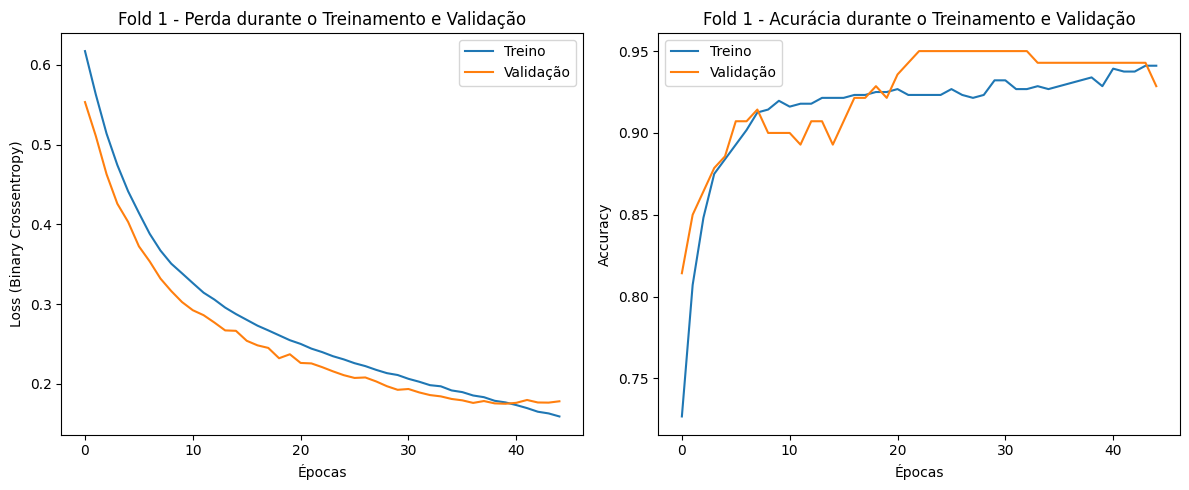

Resultados para o Fold 1:
  Acurácia: 0.9429
  Precisão: 0.6667
  Recall: 0.8571

Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


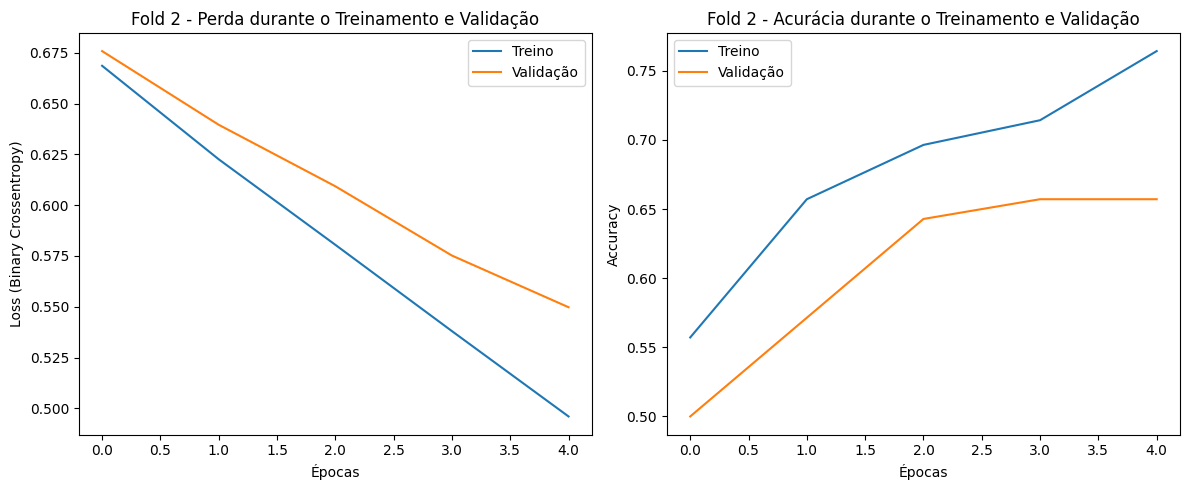

Resultados para o Fold 2:
  Acurácia: 0.5000
  Precisão: 0.0758
  Recall: 0.3571

Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


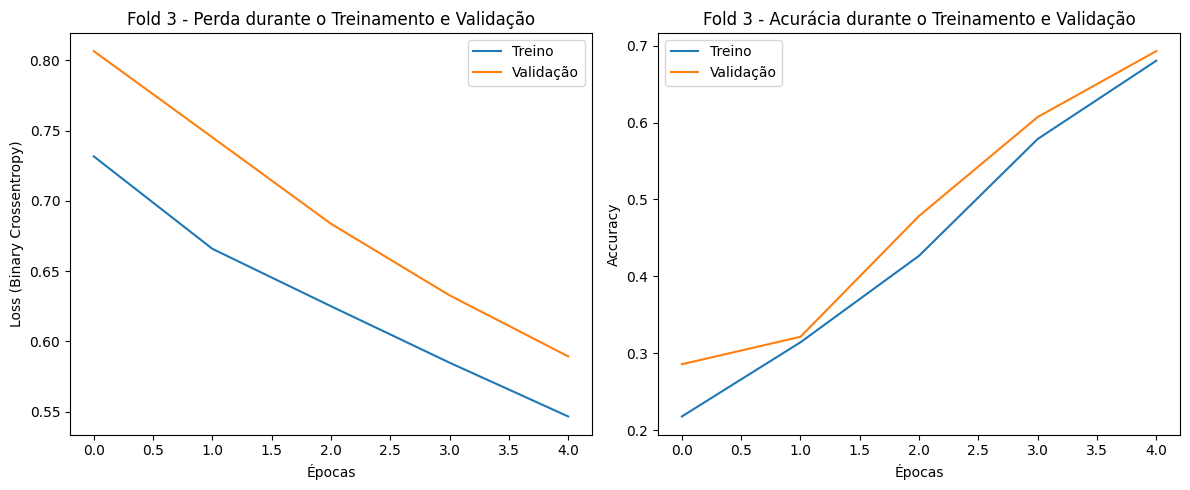

Resultados para o Fold 3:
  Acurácia: 0.2857
  Precisão: 0.0943
  Recall: 0.7143

Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


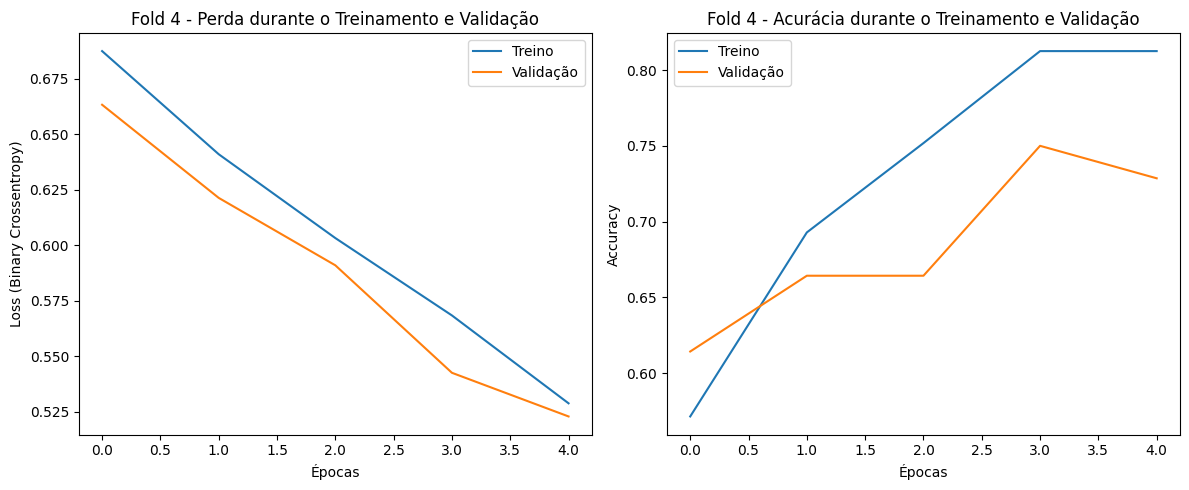

Resultados para o Fold 4:
  Acurácia: 0.6143
  Precisão: 0.1455
  Recall: 0.5333

Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 1.


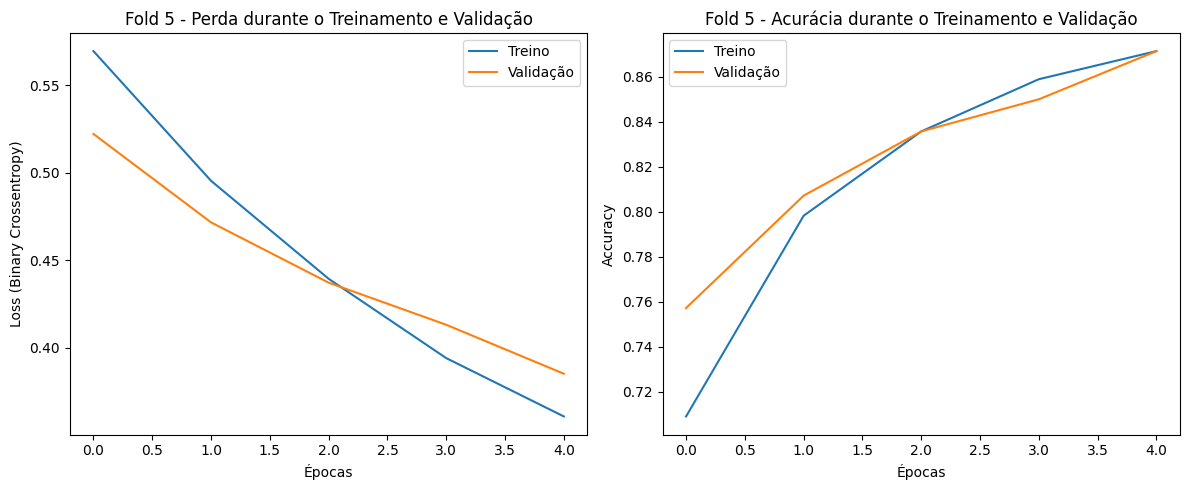

Resultados para o Fold 5:
  Acurácia: 0.7571
  Precisão: 0.2683
  Recall: 0.7333

Média dos resultados após validação cruzada:
Acurácia média: 0.6200
Precisão média: 0.2501
Recall média: 0.6390

Usando o melhor modelo (menor val_loss) para avaliação em testes...
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8833 - loss: 0.3343 - precision: 0.4583 - recall: 0.7097 
Resultados do Melhor Modelo nos Dados de Teste:
  Teste - Perda: 0.3343
  Teste - Acurácia: 0.8833
  Teste - Precisão: 0.4583
  Teste - Recall: 0.7097


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Confusion Matrix: threshold>0.3
[[226  43]
 [  4  27]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91       269
           1       0.39      0.87      0.53        31

    accuracy                           0.84       300
   macro avg       0.68      0.86      0.72       300
weighted avg       0.92      0.84      0.87       300


Accuracy: 0.8433


10/10 ━

In [ ]:
# -*- coding: utf-8 -*-
"""
Created on Tue Jul 16 11:31:22 2024

@author: Karla Figueiredo
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from sklearn.datasets import make_classification # Importing make_classification
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score # Importing evaluation metrics
import tensorflow as tf


# Gerar um conjunto de dados de exemplo que deverá ser substituido pelo conjunto de dados enviado
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, weights=[0.9, 0.1], random_state=42)

# Definindo os dados (substitua X e y com seus dados)
# Exemplo: X = np.array(...) e y = np.array(...)
# X_train e y_train representam seu conjunto de dados de entrada e rótulos


# Dividir o conjunto de dados em treinamento e teste com amostragem estratificada
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Calcular os pesos das classes
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))

print("peso das classes")
print(class_weights_dict)

# Calcular pesos das classes
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(class_weights_dict)


# Configuração da validação cruzada
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # 5-fold cross-validation com estratificação
fold_no = 1  # Número do fold para rastreamento

# Listas para armazenar as métricas por fold
accuracy_per_fold = []
precision_per_fold = []
recall_per_fold = []
val_loss_per_fold = []  # Armazena o val_loss de cada fold para escolher o melhor modelo
best_val_loss = np.inf
best_model = None  # Variável para armazenar o melhor modelo

# Configuração do Early Stopping
# restore_best_weights= True - garante que o modelo restaure os pesos da melhor época de validação antes de parar.
# patience=5 interrompe o treinamento se val_loss não melhorar por 5 épocas consecutivas.
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Loop de validação cruzada
for train_index, val_index in kf.split(X_train, y_train): # Added y_train to kf.split
    # Dividir dados em treino e validação para o fold atual
    X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
    y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

    # Criar o modelo MLP a ser avaliado com diferentes camadas e número de neurônios na camada
    model = Sequential()
    model.add(Dense(12, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilar o modelo
    model.compile(loss=BinaryCrossentropy(), optimizer=Adam(), metrics=['accuracy', Precision(), Recall()])

    # Treinar o modelo com os pesos das classes e Early Stopping
    history = model.fit(X_train_fold, y_train_fold, epochs=50, batch_size=10,
                        validation_data=(X_val_fold, y_val_fold),
                        class_weight=class_weights_dict, callbacks=[early_stopping], verbose=0)

    # Avaliar o modelo na validação atual
    scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    accuracy_per_fold.append(scores[1])
    precision_per_fold.append(scores[2])
    recall_per_fold.append(scores[3])
    val_loss_per_fold.append(scores[0])  # Armazena o val_loss atual

    # Selecionar o modelo com o menor val_loss
    if scores[0] < best_val_loss:
        best_val_loss = scores[0]
        #best_model = tf.keras.models.clone_model(model)  # Clonar o modelo
        best_model=model
        best_model.set_weights(model.get_weights())  # Copiar os pesos do modelo atual

    # Gráficos do histórico de cada fold
    plt.figure(figsize=(12, 5))

    # Plot da perda
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title(f'Fold {fold_no} - Perda durante o Treinamento e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Loss (Binary Crossentropy)')
    plt.legend()

    # Plot da acurácia
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title(f'Fold {fold_no} - Acurácia durante o Treinamento e Validação')
    plt.xlabel('Épocas')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    print(f"Resultados para o Fold {fold_no}:")
    print(f"  Acurácia: {scores[1]:.4f}")
    print(f"  Precisão: {scores[2]:.4f}")
    print(f"  Recall: {scores[3]:.4f}\n")

    fold_no += 1

# Exibir a média das métricas por fold
print("Média dos resultados após validação cruzada:")
print(f"Acurácia média: {np.mean(accuracy_per_fold):.4f}")
print(f"Precisão média: {np.mean(precision_per_fold):.4f}")
print(f"Recall média: {np.mean(recall_per_fold):.4f}")

# Usar o melhor modelo para testes finais
print("\nUsando o melhor modelo (menor val_loss) para avaliação em testes...")
test_scores = best_model.evaluate(X_test, y_test, verbose=1)
print(f"Resultados do Melhor Modelo nos Dados de Teste:")
print(f"  Teste - Perda: {test_scores[0]:.4f}")
print(f"  Teste - Acurácia: {test_scores[1]:.4f}")
print(f"  Teste - Precisão: {test_scores[2]:.4f}")
print(f"  Teste - Recall: {test_scores[3]:.4f}")



#Estudo com diferentes threshold

# Avaliar o modelo no conjunto de teste
print()
print()
y_pred = (best_model.predict(X_test) > 0.3).astype(int)

# Calcular e imprimir a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: threshold>0.3')
print(cm)

# Calcular e imprimir o relatório de classificação
cr = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(cr)

# Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')



# Avaliar o modelo no conjunto de teste
print()
print()
y_pred = (model.predict(X_test) > 0.4).astype(int)

# Calcular e imprimir a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix : threshold>0.4:')
print(cm)

# Calcular e imprimir o relatório de classificação
cr = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(cr)

# Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')


print()
print()
y_pred = (model.predict(X_test) > 0.5).astype(int)

# Calcular e imprimir a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: : threshold>0.5')
print(cm)

# Calcular e imprimir o relatório de classificação
cr = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(cr)

# Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')


print()
print()
y_pred = (model.predict(X_test) > 0.6).astype(int)

# Calcular e imprimir a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix:: threshold>0.6')
print(cm)

# Calcular e imprimir o relatório de classificação
cr = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(cr)

# Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')



print()
print()
y_pred = (model.predict(X_test) > 0.7).astype(int)

# Calcular e imprimir a matriz de confusão
cm = confusion_matrix(y_test, y_pred)
print('Confusion Matrix: : threshold>0.7')
print(cm)

# Calcular e imprimir o relatório de classificação
cr = classification_report(y_test, y_pred)
print('\nClassification Report:')
print(cr)

# Calcular e imprimir a acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f'\nAccuracy: {accuracy:.4f}')